# Phase 2: Exploratory Data Analysis — xBD Disaster Damage Data

## 1. Objective

This notebook explores the labeled building data across candidate disaster types to make an evidence-based final decision on the training set composition, and to understand the underlying data (class balance, building sizes, image resolution) before any preprocessing or modeling begins.

**Starting point:** Phase 1 confirmed `hurricane-harvey` and `hurricane-michael` as a verified, well-aligned 2-disaster training set. This phase investigates whether a 3rd training disaster is genuinely justified by real class-distribution evidence, rather than assumption or small visual samples — following the discipline established in Phase 1's `socal-fire` re-evaluation.

## 2. What This Notebook Covers

1. **2.1** — Damage-class distribution across all 10 available disaster types, in raw counts and row-wise percentages
2. **2.2** — Building size / bounding-box distribution
3. **2.3** — Image resolution consistency check
4. **2.4** — Final training set decision, backed by the class-distribution evidence

## 3. Held-Out Set

`mexico-earthquake` remains reserved exclusively for Phase 7's generalization test and is analyzed here only for its own class distribution (not as a training candidate), to keep it genuinely unseen by any training or tuning decision.

## 2.1 Damage-Class Distribution Across Disaster Types

**Task:** Count how many buildings fall into each damage class (`no-damage`, `minor-damage`, `major-damage`, `destroyed`, `un-classified`) for every disaster type in the training set — not just the current 2 training disasters, but all 10 available, so any decision about a 3rd training disaster is based on complete evidence rather than a small visual sample.

**Why this matters:** the current confirmed training set (`hurricane-harvey` + `hurricane-michael`) has only 2.5% `destroyed`-class representation combined — the most operationally important damage class for a disaster-response tool is also the most underrepresented in training data. This section quantifies that gap and checks whether any other disaster type can meaningfully close it, without duplicating existing damage patterns or compromising the integrity of the Phase 7 held-out test.

In [ ]:
import json
from collections import defaultdict
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

LABELS_DIR = Path("../data/raw/train/labels")

DISASTERS = [
    "hurricane-harvey",
    "hurricane-michael",
    "hurricane-florence",
    "hurricane-matthew",
    "santa-rosa-wildfire",
    "socal-fire",
    "midwest-flooding",
    "palu-tsunami",
    "mexico-earthquake",
    "guatemala-volcano",
]

def get_disaster_damage_counts(disaster_name, labels_dir):
    
    pattern = f"*{disaster_name}*post_disaster.json"
    
    # Finds all the matching pattern json files
    json_files = list(labels_dir.glob(pattern))
    damage_counter = defaultdict(int)
    
    for file_path in json_files:
        with open(file_path, "r") as f:
            d = json.load(f)
            for building in d.get("features", {}).get("xy", []):
                subtype = building.get("properties", {}).get("subtype")
                if not subtype:
                    subtype = "un-classified"
                damage_counter[subtype] += 1
    
    return dict(damage_counter)              

summary_results = {}
for disaster in DISASTERS:
    counts = get_disaster_damage_counts(disaster, LABELS_DIR) 
    summary_results[disaster] = counts 

contingency_table = pd.DataFrame(summary_results).T.fillna(0)

# Add a total buildings column (sum across all damage-class columns, per row)
contingency_table['total_buildings'] = contingency_table.sum(axis=1)
  
# Create a percentage version — each class as % of that disaster's own total
damage_columns = ['no-damage', 'minor-damage', 'major-damage', 'destroyed', 'un-classified']
percentage_table = contingency_table[damage_columns].div(contingency_table['total_buildings'], axis=0) * 100
percentage_table = percentage_table.round(1)
percentage_table['total_buildings'] = contingency_table['total_buildings']

print(percentage_table)


                     no-damage  minor-damage  major-damage  destroyed  \
hurricane-harvey          49.6          11.6          35.8        1.7   
hurricane-michael         64.3          23.0           8.4        3.3   
hurricane-florence        72.7           2.0          19.3        0.8   
hurricane-matthew         18.0          47.0          14.0       15.4   
santa-rosa-wildfire       71.7           0.6           0.5       26.8   
socal-fire                82.5           0.8           0.5       12.7   
midwest-flooding          92.8           1.7           1.4        0.9   
palu-tsunami              81.1           0.0           1.8       15.8   
mexico-earthquake         99.4           0.3           0.1        0.0   
guatemala-volcano         74.6           1.1           1.1        2.9   

                     un-classified  total_buildings  
hurricane-harvey               1.3            23014  
hurricane-michael              1.0            22686  
hurricane-florence             5.1

### Observations

The full 10-disaster breakdown confirms the class imbalance concern: `hurricane-harvey` (1.7% destroyed) and `hurricane-michael` (3.3% destroyed) combined leave the `destroyed` class badly underrepresented relative to `no-damage`, `minor-damage`, and `major-damage`.

Four disasters showed meaningfully higher `destroyed` representation: `santa-rosa-wildfire` (26.8%), `palu-tsunami` (15.8%), `hurricane-matthew` (15.4%), and `socal-fire` (12.7%). Each was evaluated against three criteria before selection:

1. **Does it close the actual gap?** — ranked by `destroyed`% specifically, since that's the confirmed weak point in the current training set.
2. **Does it add genuine diversity, or duplicate an existing pattern?** — `hurricane-matthew` was excluded here: despite a strong `destroyed`% (15.4%), it shares the same wind/flood damage mechanism as the existing hurricane pair and would not teach the model a new damage pattern.
3. **Does it protect the Phase 7 held-out test's integrity?** — `palu-tsunami` was excluded here: it is a real-world combined earthquake+tsunami event, and adding it to training would blur the boundary between "seen" and "unseen" damage mechanisms relative to the `mexico-earthquake` held-out disaster.

`santa-rosa-wildfire` passed all three criteria — highest `destroyed`% by a wide margin, mechanically distinct from the existing hurricane pair (fire vs. wind/flood), and does not overlap with the earthquake held-out set. It also confirmed, with full counts rather than the earlier ~15-image sample, that its `un-classified` rate (0.4%) is low — the earlier concern about fire-damage labeling quality applied to `socal-fire` specifically (3.6% un-classified, still usable but noisier), not to fire disasters in general.

**Final training set decision:** `hurricane-harvey` + `hurricane-michael` + `santa-rosa-wildfire`.
**Held-out generalization disaster (Phase 7):** `mexico-earthquake` — confirmed as mechanically and statistically distinct from all training disasters (99.4% no-damage, near-zero destroyed), remaining a genuine, uncompromised test of generalization.

`guatemala-volcano` (856 buildings, 20.3% un-classified) is confirmed too small and label-ambiguous to be useful for any purpose in this project.

## 2.2 Building Footprint Size Distribution

**Task:** For the 3 confirmed training disasters (`hurricane-harvey`, `hurricane-michael`, `santa-rosa-wildfire`), compute each building's footprint area (in square pixels) from its pre-disaster polygon, and compare the size distributions across disasters.

**Why pre-disaster labels:** damage assessment happens on post-disaster imagery, but footprint size should reflect a building's intact state — post-disaster polygons for destroyed buildings can be fragmented or reduced, which would distort the "typical building size" this section is trying to establish.

**Why this matters:** Phase 4's segmentation model needs a realistic sense of building scale to inform crop size and input resolution decisions, and to judge whether small buildings are being detected accurately once training begins.

hurricane-harvey: 23014 buildings measured
hurricane-michael: 22686 buildings measured
santa-rosa-wildfire: 12950 buildings measured


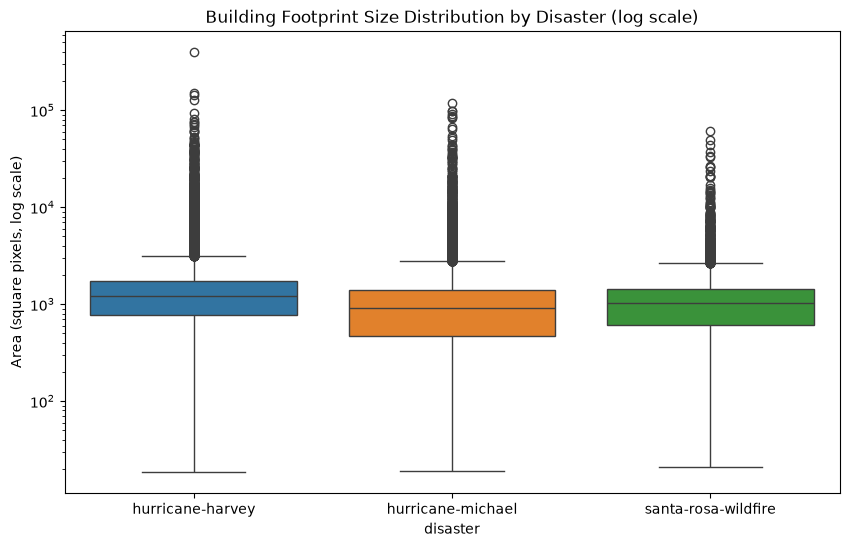

In [35]:
from shapely.wkt import loads as wkt_loads

def get_building_areas(disaster_name, labels_dir):
    
    pattern = f"*{disaster_name}*pre_disaster.json"
    json_files = list(labels_dir.glob(pattern))
    areas = []
    
    for file_path in json_files:
        with open(file_path, "r") as f:
            d = json.load(f)
            for building in d.get("features", {}).get("xy", []):
                wkt_str = building["wkt"]
                polygon = wkt_loads(wkt_str)
                areas.append(polygon.area)
    return areas

disasters = [
    "hurricane-harvey",
    "hurricane-michael",
    "santa-rosa-wildfire"
]

building_sizes = {}

for disaster in disasters:
    building_sizes[disaster] = get_building_areas(disaster, LABELS_DIR)
    print(f"{disaster}: {len(building_sizes[disaster])} buildings measured")


# Box plot needs one row per observation
plot_data = pd.DataFrame([
    {"disaster": disaster, "area" : area}
    for disaster, area_list in building_sizes.items()
    for area in area_list 
])   

plt.figure(figsize=(10, 6))
sns.boxplot(
    data=plot_data,
    x="disaster",
    y="area",
    hue="disaster",
    palette="tab10",
    legend=False
)
plt.yscale("log")
plt.title("Building Footprint Size Distribution by Disaster (log scale)")
plt.ylabel("Area (square pixels, log scale)")
plt.show()

### Observations

Building footprint sizes are consistent across all three training disasters — medians cluster tightly between ~900-1,200 square pixels, with similar interquartile ranges (roughly 500-1,700 sq px). This is a good sign for the combined training set: `santa-rosa-wildfire` was selected purely for its damage-class diversity (Section 2.1), and this confirms it doesn't also introduce a conflicting building-scale distribution the segmentation model would need to separately account for.

All three disasters show the expected right-skewed distribution with a long tail of larger outlier buildings (warehouses, commercial structures) extending up to 10⁴-10⁵ square pixels — confirming the log-scale choice was necessary for a readable comparison. `hurricane-harvey` contains the single largest outlier (~4×10⁵ sq px), most likely one unusually large structure rather than a labeling error, given the rest of its distribution is otherwise consistent with the other two disasters.

**Implication for later phases:** since building scale is consistent across the combined training set, a single augmentation/crop-size strategy (Phase 3) should generalize reasonably well across all three disasters, without requiring per-disaster tuning.